# Problem Statement 
## Design and develop an end-to-end machine learning regression system to analyze and predict energy usage using institutional energy data. The project involves selecting a suitable numerical dataset containing features such as time of day, number of students present, ambient temperature, and appliance usage. Data preprocessing steps including data cleaning, normalization, and feature transformation are applied to ensure data quality and consistency. Exploratory Data Analysis is performed to study consumption patterns, detect outliers, and analyze correlations between features using statistical summaries and visualizations such as line plots, histograms, and correlation heatmaps. Based on insights obtained from EDA, relevant features are selected to improve model performance (PCA, Forward Selection, Backward Selection). A machine learning regression model is then developed and evaluated to predict energy usage, demonstrating a complete machine learning workflow from raw data to evaluated predictive models.

In [78]:
# Importing necessary Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [79]:
# Load the original raw dataset
df = pd.read_csv("energy_usage.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (14000, 19)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T_out,RH_out,Press_mm_hg,Windspeed,Visibility,Tdewpoint
0,09-04-2016 14:20,100.000000,30.0,22.20,NaN,21.600000,34.790000,22.290000,37.066667,20.963333,36.826667,20.000000,44.038000,13.000000,51.000000,749.400000,7.333333,40.0,3.00
1,15-01-2016 00:20,50.000000,20.0,23.70,39.560000,22.790000,39.400000,21.200000,43.260000,18.700000,44.022500,18.633333,55.730000,0.533000,96.000000,749.266667,9.333333,46.0,NaN
2,18-02-2016 17:00,100.000000,10.0,20.00,33.966667,18.323333,34.900000,19.725714,36.290000,18.666667,33.933333,17.290000,42.790000,3.100000,79.000000,756.200000,2.000000,29.0,-0.30
3,17-02-2016 16:30,90.000000,10.0,20.89,33.590000,19.290000,33.900000,20.200000,35.440000,19.390000,88.500400,17.754000,43.656000,2.800000,75.000000,757.050000,2.500000,21.5,-1.25
4,02-02-2016 18:50,117.557151,10.0,21.76,48.566667,21.390000,43.826667,22.042857,45.860714,20.500000,46.156667,20.100000,48.542778,12.278668,84.166667,757.483333,5.833333,40.0,4.63


In [80]:
# See the column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T_out', 'RH_out', 'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint']


In [81]:
# Structural info — data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         13860 non-null  object 
 1   Appliances   13724 non-null  float64
 2   lights       13448 non-null  float64
 3   T1           13175 non-null  float64
 4   RH_1         13177 non-null  float64
 5   T2           13175 non-null  float64
 6   RH_2         13181 non-null  float64
 7   T3           13182 non-null  float64
 8   RH_3         13182 non-null  float64
 9   T4           13178 non-null  float64
 10  RH_4         13175 non-null  float64
 11  T5           13174 non-null  float64
 12  RH_5         13172 non-null  float64
 13  T_out        13452 non-null  float64
 14  RH_out       13450 non-null  float64
 15  Press_mm_hg  13446 non-null  float64
 16  Windspeed    13456 non-null  float64
 17  Visibility   13450 non-null  float64
 18  Tdewpoint    13449 non-null  float64
dtypes: f

In [82]:
# Statistical summary — mean, min, max etc.
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T_out,RH_out,Press_mm_hg,Windspeed,Visibility,Tdewpoint
count,13724.000000,13448.000000,13175.000000,13177.000000,13175.000000,13181.000000,13182.000000,13182.000000,13178.000000,13175.000000,13174.000000,13172.000000,13452.000000,13450.000000,13446.000000,13456.000000,13450.000000,13449.000000
mean,102.720749,17.484891,21.817767,40.942873,20.478943,41.102733,22.399339,39.937381,20.996781,39.696913,19.734479,51.072441,7.664663,80.040719,755.908619,4.220651,38.247347,3.965091
std,135.111360,10.152673,1.819221,6.790186,2.386955,6.756540,2.211329,6.487780,2.252993,6.924647,2.098359,9.146052,5.590484,14.852076,7.755030,2.701492,11.144585,4.432073
min,10.000000,10.000000,16.790000,27.023333,16.100000,20.893333,17.200000,29.293333,15.100000,27.660000,15.330000,30.030000,-4.990000,24.000000,729.333333,0.000000,1.000000,-6.600000
25%,50.000000,10.000000,20.790000,37.400000,18.890000,37.925000,20.790000,36.900000,19.600000,35.560000,18.290000,45.433333,3.720000,70.333333,751.000000,2.000000,29.000000,0.967000
50%,60.000000,20.000000,21.633333,39.726667,20.085714,40.560000,22.133333,38.590000,20.700000,38.500000,19.431389,49.200000,7.050000,84.000000,756.200000,3.833333,40.000000,3.500000
75%,100.000000,20.000000,22.700000,43.266667,21.700000,43.526667,23.463333,42.000000,22.237929,42.500000,20.700000,54.000833,10.700000,92.000000,761.400000,5.833333,40.000000,6.830000
max,1099.853500,89.824600,31.995200,94.984800,31.991500,94.975000,32.999300,94.968400,31.931700,94.981800,30.859600,95.953889,27.989800,100.000000,779.861400,15.991800,66.000000,17.997700


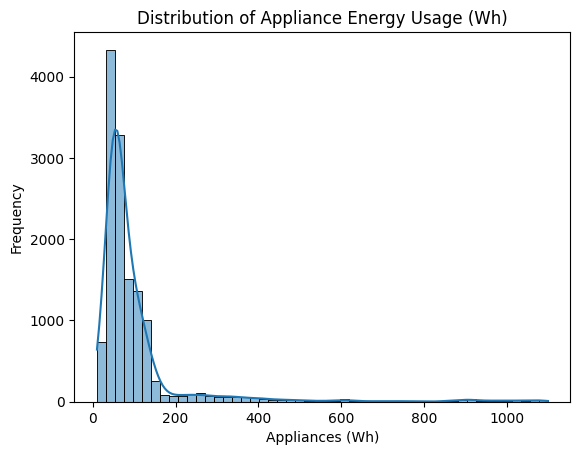

In [83]:
sns.histplot(df['Appliances'].dropna(), bins=50,kde=True)
plt.title("Distribution of Appliance Energy Usage (Wh)")
plt.xlabel("Appliances (Wh)")
plt.ylabel("Frequency")
# plt.tight_layout()
plt.show()

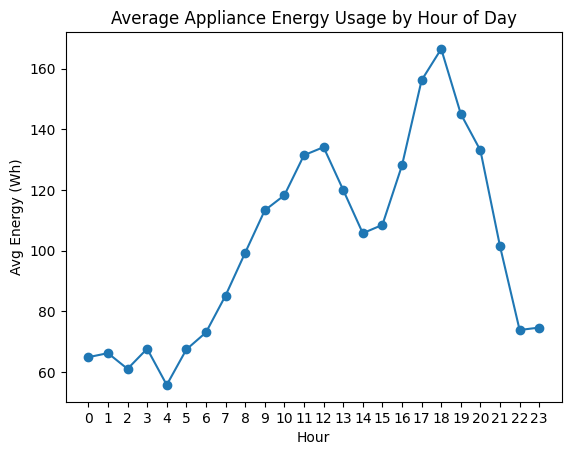

In [84]:
# Convert date column to datetime so we can extract hour/month
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")

# Average energy usage by hour of day
df['hour'] = df['date'].dt.hour
hourly_avg = df.groupby('hour')['Appliances'].mean()
# plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title("Average Appliance Energy Usage by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Energy (Wh)")
plt.xticks(range(0, 24))
plt.show()

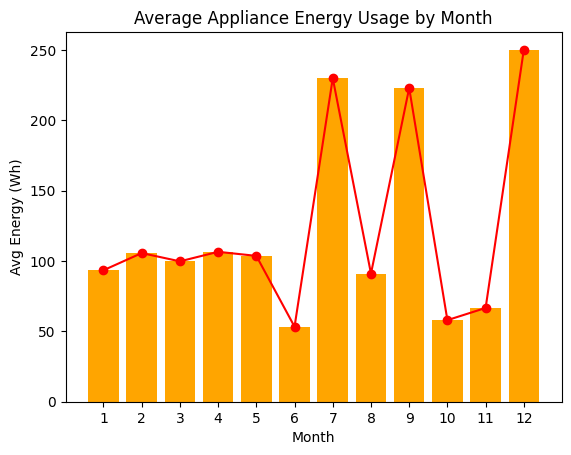

In [85]:
# Average energy usage by month
df['month'] = df['date'].dt.month
monthly_avg = df.groupby('month')['Appliances'].mean()

plt.bar(monthly_avg.index, monthly_avg.values, color="orange")
plt.plot(monthly_avg.index, monthly_avg.values, marker="o", color="red")
plt.title("Average Appliance Energy Usage by Month")
plt.xlabel("Month")
plt.ylabel("Avg Energy (Wh)")
plt.xticks(range(1, 13))
plt.show()


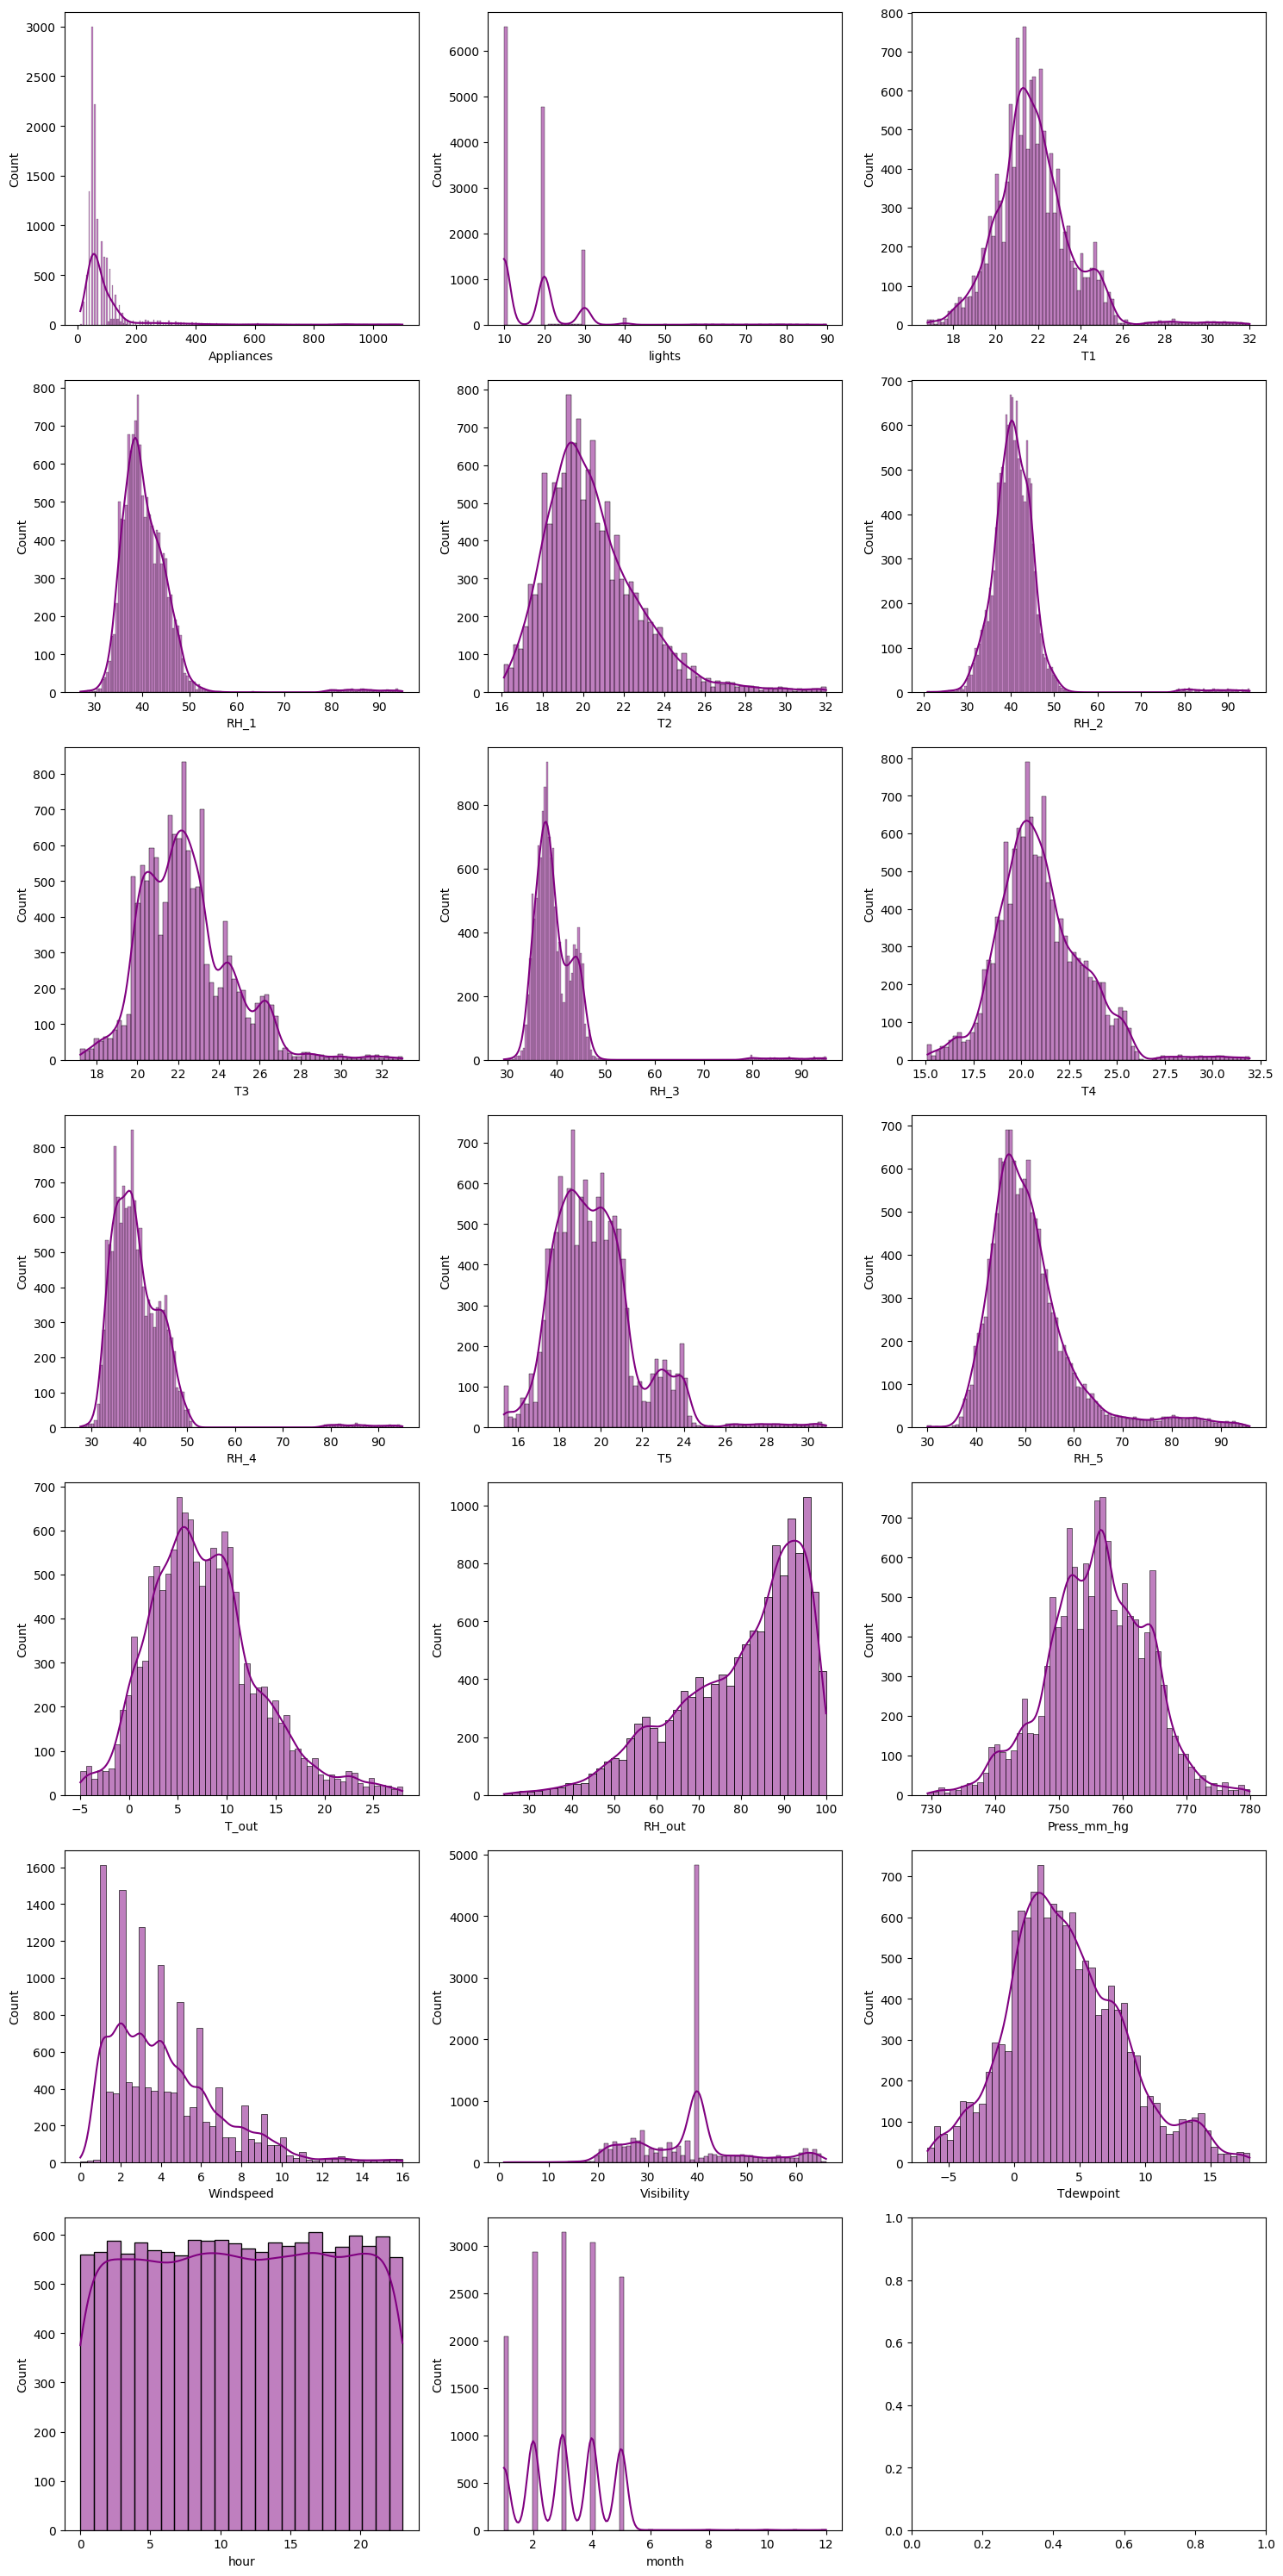

In [86]:
# Histogram of all numerical features — check skewness
numerical_cols=[]
for col in df.columns:
    if df[col].dtype in ["float","int"] :
        numerical_cols.append(col)

fig, axes = plt.subplots(7, 3, figsize=(15,30))
axes=axes.flatten()
for i,col in enumerate(numerical_cols): 
    sns.histplot(df[col],kde = True , color="purple", ax=axes[i])
    # plt.title (f"distribution of {col}")
plt.tight_layout()
plt.show()


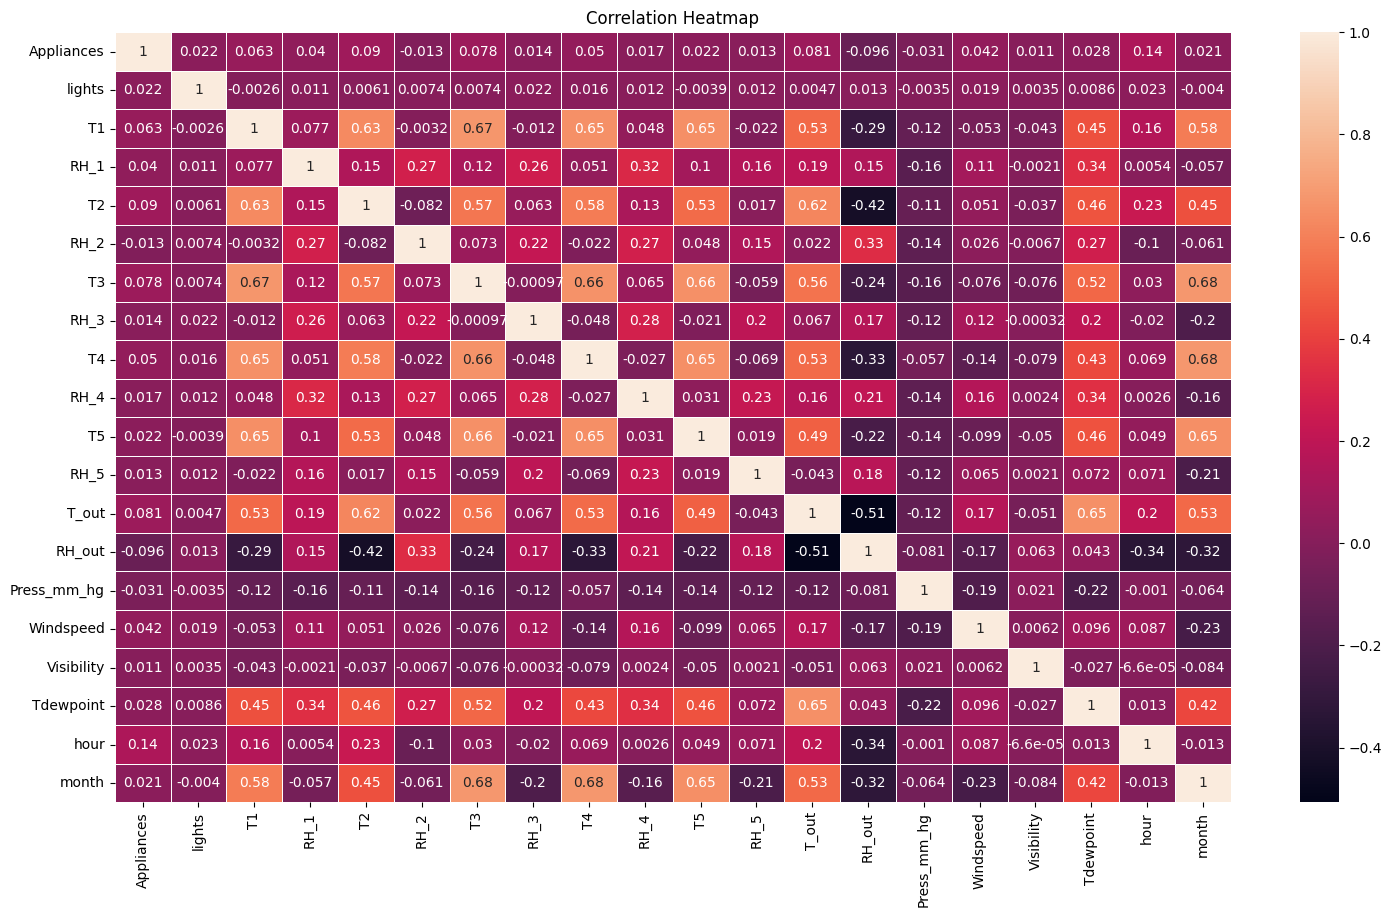

In [87]:
# Correlation heatmap — which features are related to each other.
corr = df[numerical_cols].corr()
plt.figure(figsize=(18, 10))
sns.heatmap(corr, annot=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [88]:
# Features correlated with Appliances (target)
appliance_corr = corr['Appliances'].drop('Appliances').sort_values(ascending=False)
print("Correlation with Appliances (Energy Usage):")
print(appliance_corr)

Correlation with Appliances (Energy Usage):
hour           0.139649
T2             0.090032
T_out          0.080641
T3             0.078183
T1             0.062558
T4             0.049936
Windspeed      0.042392
RH_1           0.040164
Tdewpoint      0.027740
T5             0.022445
lights         0.021623
month          0.020518
RH_4           0.016561
RH_3           0.013816
RH_5           0.013421
Visibility     0.010891
RH_2          -0.013415
Press_mm_hg   -0.031349
RH_out        -0.095724
Name: Appliances, dtype: float64


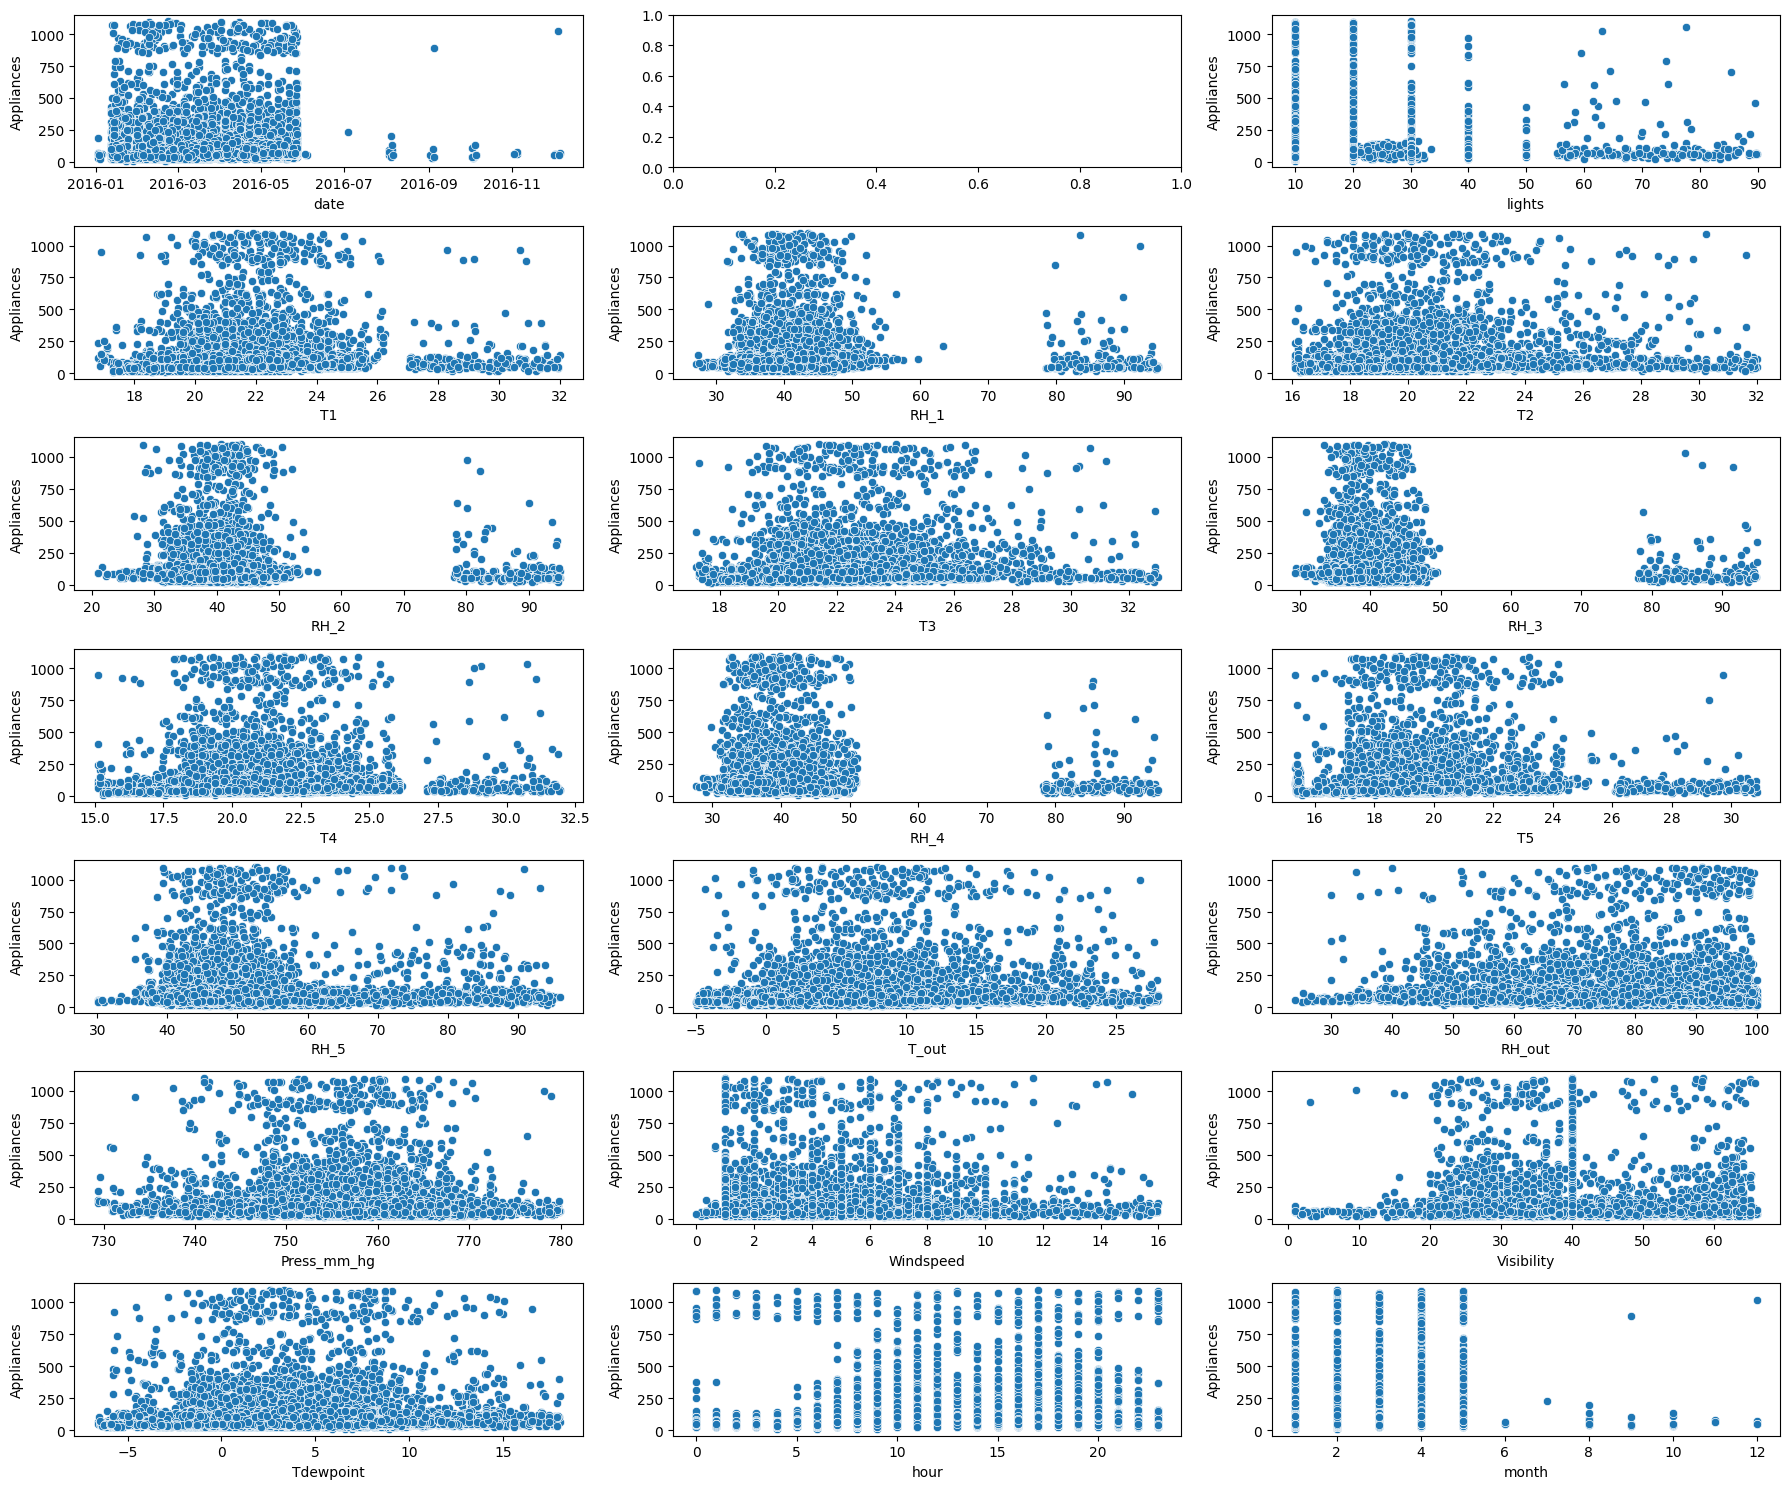

In [89]:
# Scatter plot - check for outliers and relation of features with target
fig, axes = plt.subplots(7,3, figsize=(18,15))
axes=axes.flatten()
for i,col in enumerate(df.columns) :
    if col != "Appliances" : 
        sns.scatterplot(data=df ,x=col , y="Appliances" ,ax= axes[i])
plt.tight_layout()
plt.show()

# Data cleaning and Handling Missing Values

In [90]:

# Check missing values count per column
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
date           140
Appliances     276
lights         552
T1             825
RH_1           823
T2             825
RH_2           819
T3             818
RH_3           818
T4             822
RH_4           825
T5             826
RH_5           828
T_out          548
RH_out         550
Press_mm_hg    554
Windspeed      544
Visibility     550
Tdewpoint      551
hour           140
month          140
dtype: int64


In [91]:
# Drop rows where Appliances(target) or date is missing
df.dropna(subset=['date', 'Appliances'], inplace=True)
print("Shape after dropping rows with missing target:", df.shape)

Shape after dropping rows with missing target: (13586, 21)


In [92]:
# check Duplicate value count
duplicate_rows = df.duplicated().sum()
print(f"No. of Duplicate rows : {duplicate_rows}")

No. of Duplicate rows : 14


In [93]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f"Removed {duplicate_rows} duplicate rows")
print("Shape now:", df.shape)

Removed 14 duplicate rows
Shape now: (13572, 21)


In [94]:
# Imputing Null values
# If a column is roughly symmetric (skew between -0.5 and 0.5) → use mean
# If right-skewed (skew > 0.5) → use median
# If left-skewed (skew < -0.5) → use median

null_cols = [col for col in df.columns if df[col].isnull().sum() > 0 and col != "date"]
for feature in null_cols : 
    skewness= df[feature].skew()
    if skewness >= -0.5 and skewness <= 0.5:    # Normal Distribution 
        df[feature].fillna(df[feature].mean(), inplace = True)
        print(f"{feature} :- {skewness} , imputed with mean {df[col].mean()}")
    elif skewness > 0.5 :            # right skewed 
        df[feature].fillna(df[feature].median(), inplace = True)
        print(f"{feature} :- {skewness} , imputed with median {df[col].median()}")
    elif skewness < -0.5 :           # Left skewed
        df[feature].fillna(df[feature].median(), inplace = True)
        print(f"{feature} :- {skewness} , imputed with median {df[col].median()}")
print(f"Missing Value : {df.isnull().sum().sum()}")

lights :- 2.785449331623133 , imputed with median 3.0
T1 :- 1.063112499498403 , imputed with median 3.0
RH_1 :- 4.4329740596519125 , imputed with median 3.0
T2 :- 1.2376970545301653 , imputed with median 3.0
RH_2 :- 4.224905643985027 , imputed with median 3.0
T3 :- 0.9110897027075049 , imputed with median 3.0
RH_3 :- 5.398011339420387 , imputed with median 3.0
T4 :- 0.7916428624201393 , imputed with median 3.0
RH_4 :- 4.0501149552869276 , imputed with median 3.0
T5 :- 1.287899875784225 , imputed with median 3.0
RH_5 :- 1.9284299537896115 , imputed with median 3.0
T_out :- 0.6655484900953925 , imputed with median 3.0
RH_out :- -0.8713966989542299 , imputed with median 3.0
Press_mm_hg :- -0.164159104220583 , imputed with mean 3.1122163277335693
Windspeed :- 1.1362946759940857 , imputed with median 3.0
Visibility :- 0.4009513385471281 , imputed with mean 3.1122163277335693
Tdewpoint :- 0.3969183382487642 , imputed with mean 3.1122163277335693
Missing Value : 0


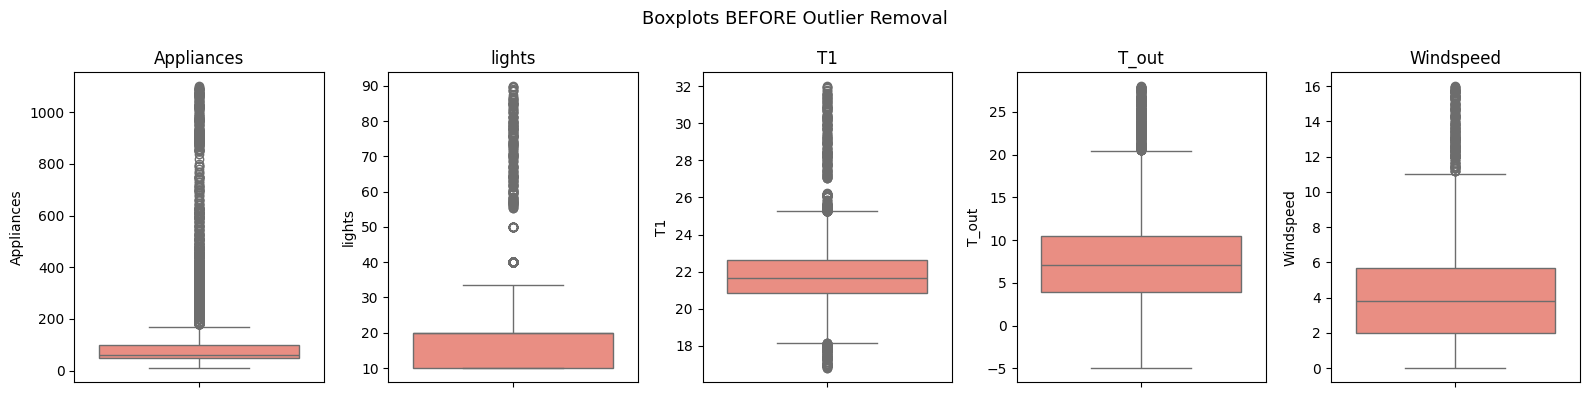

In [95]:
# Show boxplots BEFORE removing outliers for key columns
key_cols = ['Appliances', 'lights', 'T1', 'T_out', 'Windspeed']
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes=axes.flatten()
for i, col in enumerate(key_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(col)
plt.suptitle("Boxplots BEFORE Outlier Removal", fontsize=13)
plt.tight_layout()
plt.show()

In [96]:
numerical_features = [col for col in df.columns if col not in ['date'] and df[col].dtype != 'object']

print("Shape BEFORE outlier removal:", df.shape)

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape AFTER outlier removal:", df.shape)

Shape BEFORE outlier removal: (13572, 21)
Shape AFTER outlier removal: (8014, 21)


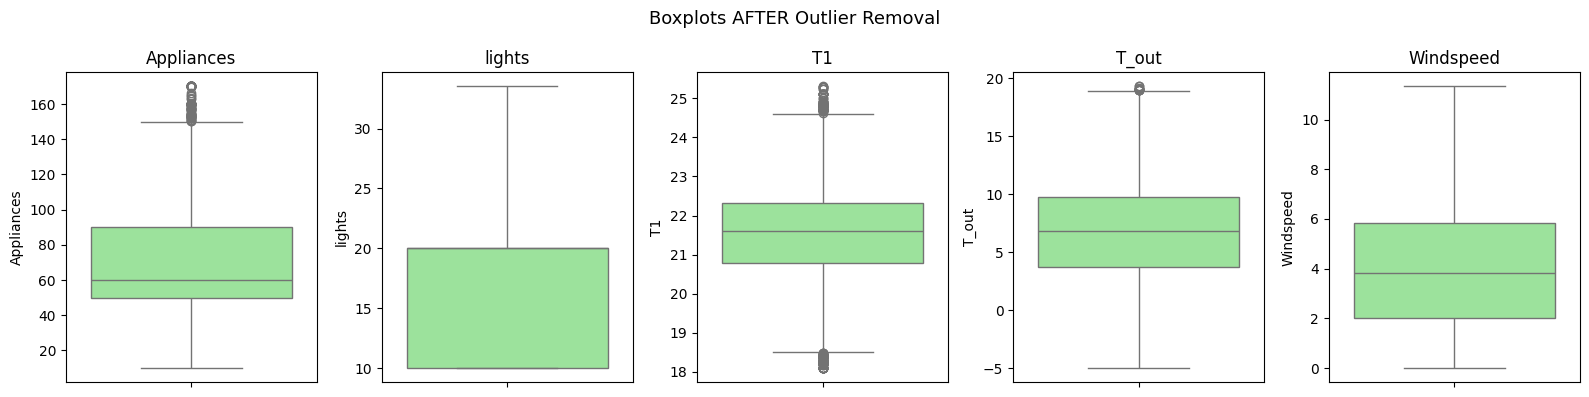

In [97]:
# Show boxplots AFTER removing outliers
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes=axes.flatten()
for i, col in enumerate(key_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col)
plt.suptitle("Boxplots AFTER Outlier Removal", fontsize=13)
plt.tight_layout()
plt.show()

# Standardization

In [98]:
# seperate features
feature_x = df.drop(["Appliances","date"] , axis=1)
print("Features shape:", feature_x.shape)
print(f"Feature columns : {feature_x.columns.to_list()}")

Features shape: (8014, 19)
Feature columns : ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T_out', 'RH_out', 'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'month']


In [99]:
# Apply StandardScaler to normalize all feature columns
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(feature_x), columns = feature_x.columns)
scaled.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T_out,RH_out,Press_mm_hg,Windspeed,Visibility,Tdewpoint,hour,month
0,1.945110,0.506343,-0.077217,0.915396,-1.631091,0.113936,-0.659619,0.159001,-0.482616,0.392631,-0.950905,1.414153,-2.281924,-0.920432,1.305161,0.462874,-0.110353,0.409205,0.769023
1,0.509472,1.671680,-0.125934,1.617863,-0.317913,-0.550461,1.348400,-1.204478,1.268985,-0.528699,1.077019,-1.429024,1.147565,-0.939099,2.127362,1.189637,0.154433,-1.595387,-1.616019
2,-0.926166,-1.202818,-1.728826,-1.018848,-1.599757,-1.449096,-0.911432,-1.224559,-1.186907,-1.434298,-1.167365,-0.843604,-0.148020,0.031575,-0.887376,-0.869526,-1.010521,0.838760,-0.821005
3,-0.926166,0.164511,2.455122,0.791431,0.943041,-0.036707,2.191610,-0.120120,1.788481,0.460046,-0.169572,1.249648,0.245736,0.211244,0.688510,0.462874,0.334276,0.981945,-0.821005
4,1.945110,-0.348238,-0.744929,-1.170361,-0.147001,-0.129880,-0.887656,0.141330,-0.905353,0.190388,-0.114551,-1.071660,0.944336,-1.037100,-0.476276,0.462874,-0.620448,-1.165831,0.769023


# Feature Selection
### To pick the most useful Feature we use :-
### 1. Forward Selection : starts with 0 features and adds the best one at a time
### 2. Backward Selection : starts with all features and removes the worst one at a time
### 3. PCA : reduces many features into fewer "summary" components

In [100]:
# Splitting Feature columns and Target column 
x = scaled
y = df["Appliances"] 

In [101]:
y

0        100.000000
1         50.000000
2        100.000000
4        117.557151
7         60.000000
            ...    
13989     50.000000
13990    100.000000
13995    120.000000
13996     40.000000
13998    100.000000
Name: Appliances, Length: 8014, dtype: float64

In [102]:
model = LinearRegression()

# Forward Selection

In [103]:

fs = SequentialFeatureSelector(model, n_features_to_select= 'auto', direction='forward')
fs.fit(x, y)


,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",'auto'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [104]:

selected_features = x.columns[fs.get_support()]
print("Selected features are : ",selected_features)

Selected features are :  Index(['T1', 'RH_1', 'RH_2', 'T3', 'RH_3', 'RH_out', 'Press_mm_hg', 'hour',
       'month'],
      dtype='object')


# Backward Selection

In [105]:

be = SequentialFeatureSelector(model, n_features_to_select='auto', direction='backward')
be.fit(x, y)

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",'auto'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'backward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [106]:
selected_rev_features = x.columns[be.get_support()]
print("Selected Features are : ",selected_rev_features)

Selected Features are :  Index(['T1', 'RH_1', 'RH_2', 'T3', 'RH_3', 'Press_mm_hg', 'Windspeed',
       'Tdewpoint', 'hour', 'month'],
      dtype='object')


# PCA

In [107]:
pca = PCA()
X_pca = pca.fit_transform(scaled)
pd.DataFrame(X_pca)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.897689,-1.355008,-2.733784,-1.017863,2.053792,-0.817994,-0.187202,-0.416980,-0.151883,-0.510226,-0.251562,-0.251916,0.368825,0.240428,-0.177268,-0.132151,0.353852,0.472181,0.088135
1,-1.045579,2.476462,-0.720425,-0.887432,0.644679,0.714114,1.493746,-2.394404,-2.263532,1.241643,1.289961,-0.546779,-0.323587,-0.291736,-1.002868,-0.336443,-0.202542,0.156734,-0.589475
2,-3.084075,-2.949380,-0.772683,0.031981,-1.055495,-0.634553,-0.261971,1.114380,-0.443753,-0.461422,0.699821,-0.126986,-0.023684,-0.402040,0.278788,-0.104495,0.069316,-0.118451,-0.072843
3,0.824500,3.643794,-1.092295,0.551663,-0.929330,0.816750,-0.766852,0.718964,-0.872932,0.002125,-0.824472,0.138366,0.514554,0.172389,0.226928,-0.297315,0.342198,0.215696,0.801244
4,-0.943626,-1.395966,1.815956,-1.041953,2.221883,-0.337630,0.947541,-0.209564,0.205347,-0.049302,0.060106,0.233363,0.201120,0.049859,-0.024326,0.021998,0.075971,0.263854,0.010984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8009,-1.296606,1.531147,0.809501,1.082294,-1.029525,1.415344,0.240567,-1.322475,-0.358267,0.125165,-0.415508,-0.211423,0.159153,0.240641,0.494808,-0.234750,-0.169711,0.043157,0.025562
8010,-1.855178,-1.740091,-0.728113,0.315955,-1.291003,-1.621209,0.162095,1.401411,-0.686266,-0.212790,-0.007494,0.142517,-0.109277,0.312755,-0.284359,-0.081601,0.479715,-0.297567,-0.047880
8011,0.078394,1.782272,-0.519912,1.879355,1.171889,0.919305,0.453939,0.084653,-0.168982,0.232766,-1.064752,0.289735,-0.711081,0.373245,0.450204,-0.318604,-0.060320,-0.105372,-0.023901
8012,-2.213943,-1.253758,2.193639,-1.191414,-0.380342,1.089923,-0.236857,0.349322,-0.496549,-0.502499,-0.016331,0.733588,-0.182037,-0.017422,-0.052260,0.278650,0.006559,0.031633,0.064023


In [108]:

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.28269158, 0.22635911, 0.0975634 , 0.05666031, 0.05258099,
       0.05098539, 0.04623228, 0.03957313, 0.02917083, 0.02587821,
       0.02304694, 0.01388374, 0.01198767, 0.0108361 , 0.00894833,
       0.0076641 , 0.00624487, 0.00589875, 0.00379427])

In [109]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance


array([0.28269158, 0.50905068, 0.60661409, 0.6632744 , 0.71585539,
       0.76684078, 0.81307305, 0.85264618, 0.88181701, 0.90769522,
       0.93074215, 0.94462589, 0.95661356, 0.96744967, 0.976398  ,
       0.9840621 , 0.99030697, 0.99620573, 1.        ])

In [110]:

n_components = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components (95% variance):", n_components)

Number of components (95% variance): 13


In [111]:
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(scaled)
pd.DataFrame(X_reduced)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.897689,-1.355008,-2.733784,-1.017863,2.053792,-0.817994,-0.187202,-0.416980,-0.151883,-0.510226,-0.251562,-0.251916,0.368825
1,-1.045579,2.476462,-0.720425,-0.887432,0.644679,0.714114,1.493746,-2.394404,-2.263532,1.241643,1.289961,-0.546779,-0.323587
2,-3.084075,-2.949380,-0.772683,0.031981,-1.055495,-0.634553,-0.261971,1.114380,-0.443753,-0.461422,0.699821,-0.126986,-0.023684
3,0.824500,3.643794,-1.092295,0.551663,-0.929330,0.816750,-0.766852,0.718964,-0.872932,0.002125,-0.824472,0.138366,0.514554
4,-0.943626,-1.395966,1.815956,-1.041953,2.221883,-0.337630,0.947541,-0.209564,0.205347,-0.049302,0.060106,0.233363,0.201120
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8009,-1.296606,1.531147,0.809501,1.082294,-1.029525,1.415344,0.240567,-1.322475,-0.358267,0.125165,-0.415508,-0.211423,0.159153
8010,-1.855178,-1.740091,-0.728113,0.315955,-1.291003,-1.621209,0.162095,1.401411,-0.686266,-0.212790,-0.007494,0.142517,-0.109277
8011,0.078394,1.782272,-0.519912,1.879355,1.171889,0.919305,0.453939,0.084653,-0.168982,0.232766,-1.064752,0.289735,-0.711081
8012,-2.213943,-1.253758,2.193639,-1.191414,-0.380342,1.089923,-0.236857,0.349322,-0.496549,-0.502499,-0.016331,0.733588,-0.182037


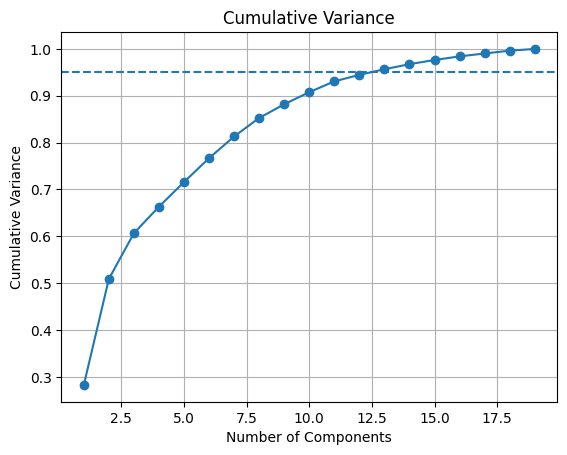

In [112]:
# Cumulative Variance Plot
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, linestyle='--')
plt.title("Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

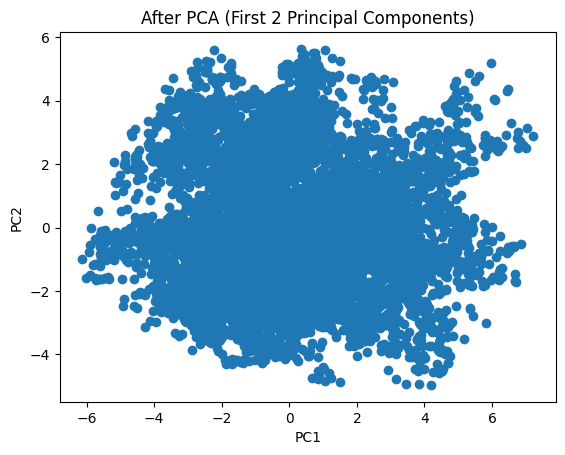

In [113]:
# After PCA (first 2 principal components)
plt.figure()
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.title("After PCA (First 2 Principal Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Model Building and Evaluation 

In [114]:

# Use the Forward Selected features for modelling
x_model = scaled[selected_features]
y_model = y.reset_index(drop=True)

# Split into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(x_model, y_model, test_size=0.2, random_state=42)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 6411
Testing samples: 1603


In [115]:
# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [116]:
y_pred=lr.predict(x_test)

In [117]:
# Applying MAE, RMSE, R2 score to check the model performance 
mae_lr  = mean_absolute_error(y_test, y_pred)
mse_lr  = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr   = r2_score(y_test, y_pred)

In [118]:
print("-----Linear Regression Model----")
print("MAE : ",mae_lr)
print("MSE : ",mse_lr)
print("RMSE : ",rmse_lr)
print("R2 : ",r2_lr)

-----Linear Regression Model----
MAE :  20.76676593274749
MSE :  758.5574063083174
RMSE :  27.541920889950966
R2 :  0.19653220988662334


In [119]:
r2_result = []
for x in range(100,1000,100):
    rf = RandomForestRegressor(n_estimators=x, random_state=42)
    rf.fit(x_train, y_train)
    y_predict=rf.predict(x_test)
    r2_result.append(r2_score(y_test,y_predict))

[]

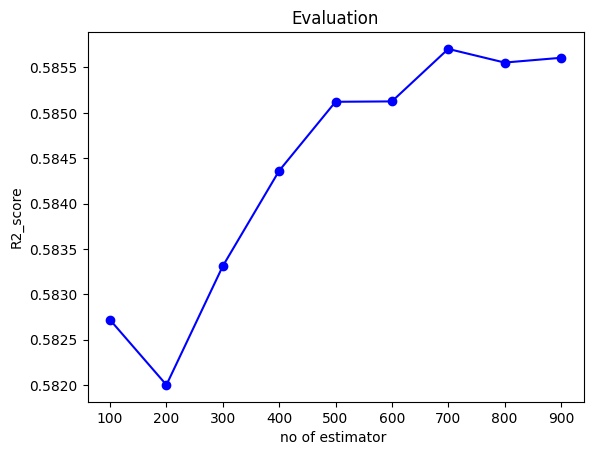

In [120]:
plt.figure()
plt.plot(list(x for x in range(100,1000,100)), r2_result,color="blue", marker="o")
plt.title("Evaluation")
plt.xlabel("no of estimator ")
plt.ylabel("R2_score")
plt.plot()

In [121]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=600, random_state=42)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [122]:
y_predict_rf=rf.predict(x_test)

In [123]:
# Applying MAE, RMSE, R2 score to check the model performance 
mae_rf  = mean_absolute_error(y_test, y_predict_rf)
mse_rf  = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_predict_rf))
r2_rf   = r2_score(y_test, y_predict_rf)

In [124]:
print("-----Random Forest Regression----")
print("MAE : ",mae_rf)
print("MSE : ",mse_rf)
print("RMSE : ",rmse_rf)
print("R2 : ",r2_rf)

-----Random Forest Regression----
MAE :  13.783688140512847
MSE :  758.5574063083174
RMSE :  19.791015014185746
R2 :  0.5851260610289403


In [125]:
gb = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)
gb.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [126]:
gb.n_estimators_

419

In [127]:
y_predict_gb=gb.predict(x_test)

In [128]:
# Applying MAE, RMSE, R2 score to check the model performance 
mae_gb  = mean_absolute_error(y_test, y_predict_gb)
mse_gb  = mean_squared_error(y_test, y_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_predict_gb))
r2_gb   = r2_score(y_test, y_predict_gb)

In [129]:
print("-----Gradient Boosting Regression----")
print("MAE : ",mae_gb)
print("MSE : ",mse_gb)
print("RMSE : ",rmse_gb)
print("R2 : ",r2_gb)

-----Gradient Boosting Regression----
MAE :  16.560388572025374
MSE :  758.5574063083174
RMSE :  23.00248599178888
R2 :  0.4395594275934529


In [130]:
# Compare all three models in a table
results_df = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE'   : [mae_lr, mae_rf, mae_gb],
    'RMSE'  : [rmse_lr, rmse_rf, rmse_gb],
    'R2'    : [r2_lr, r2_rf, r2_gb]
})


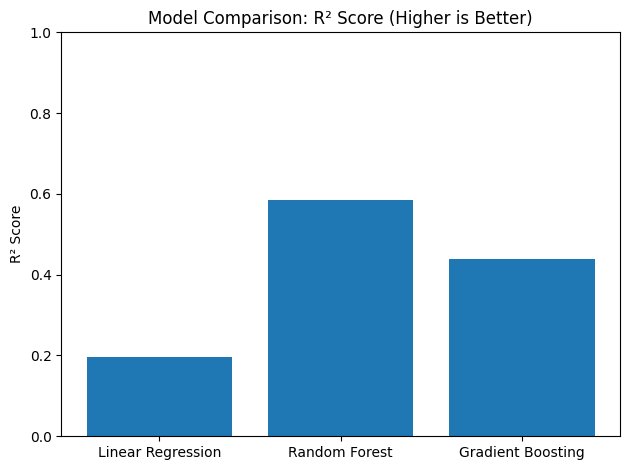

In [131]:
# Bar chart comparison of R² scores
bars = plt.bar(results_df['Model'], results_df['R2'])
plt.title("Model Comparison: R² Score (Higher is Better)")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [132]:
import joblib

In [ ]:
joblib.dump(rf,"Model_best.pkl")
joblib.dump(scaler,"Scaling.pkl")
joblib.dump(fs,"Feature_selection.pkl")

['Feature_selection.pkl']

: 